# Pinwheel Test

Use a moving pinwheel to test the response of our filter bank

In [1]:
from PIL import Image, ImageSequence
import matplotlib.pyplot as plt
import numpy as np
import pickle
import torch
import torch.nn.functional as F


torch.Size([1, 1, 80, 500, 500])


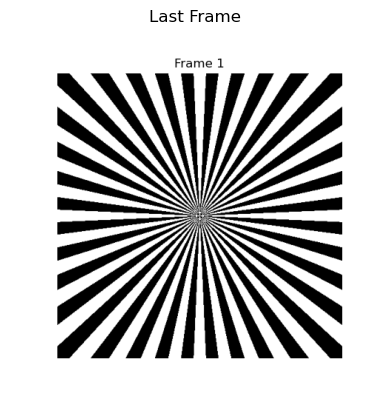

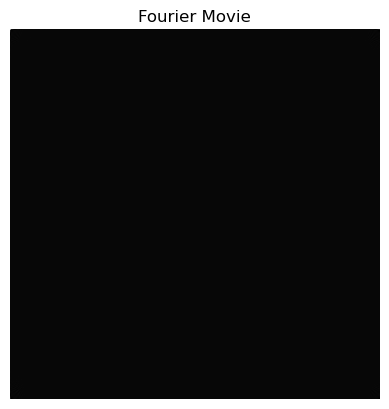

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

test_type = 'pinwheel' #'pinwheel'
n_movie_frames = 80

# Path to your AVI file
if(test_type=='pinwheel'):
    test_movie = './siemens_star/siemens_star_rotation.avi'
elif(test_type=='water'):
    test_movie = './texture_examples/water.mp4'

    
# Open the video file
cap = cv2.VideoCapture(test_movie)

# Check if the video opened successfully
if not cap.isOpened():
    print(f"Error: Unable to open video file '{test_movie}'")
    exit()

# Initialize list to store frames
movie = []

# Read frames from the video
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Convert frame to grayscale if necessary
    if frame.ndim > 2:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    movie.append(frame)

# Convert list of frames to numpy array & PyTorch tensor
movie = np.array(movie)
movie = torch.from_numpy(movie)
movie = movie.unsqueeze(0)  # Add a channel dimension (for grayscale)
movie = movie.unsqueeze(0)  # Add a channel dimension (for grayscale)
# Convert to float tensor (if needed)
movie = movie.float()
#take only the first n frames of the movie
movie = movie[:,:,:n_movie_frames,:,:]



fftmov = torch.fft.fftn(movie)
ufftmov = torch.fft.ifftn(fftmov)

print(movie.shape)
# if(test_movie=='pinwheel'):
plt.imshow(ufftmov[0][0][0].real, cmap='gray')  # Show the last frame
plt.title('Last Frame')
plt.axis('off')
plt.show()

plt.imshow(fftmov[0][0][0].real, cmap='gray')  # Show the last frame
plt.title('Fourier Movie')
plt.axis('off')
plt.show()


# Release the video capture object and close all windows
cap.release()
cv2.destroyAllWindows()


In [3]:
print(movie.shape)

torch.Size([1, 1, 80, 500, 500])


## Load in our Spatiotemporal Filter Bank

In [4]:
normalize=False
filter_banks_size = 32
with open(f'./filter_banks_norm{normalize}_{filter_banks_size}/filters_torch.pkl', 'rb') as f:
    filters = pickle.load(f)

In [5]:
#filters['spatiotemporal']['im'].keys()
filters['fourier']['im'].keys()

dict_keys(['1-0-1', '1-0-2', '1-0-4', '1-45-1', '1-45-2', '1-45-4', '1-90-1', '1-90-2', '1-90-4', '1-135-1', '1-135-2', '1-135-4', '1-180-1', '1-180-2', '1-180-4', '1-225-1', '1-225-2', '1-225-4', '1-270-1', '1-270-2', '1-270-4', '1-315-1', '1-315-2', '1-315-4', '2-0-1', '2-0-2', '2-0-4', '2-45-1', '2-45-2', '2-45-4', '2-90-1', '2-90-2', '2-90-4', '2-135-1', '2-135-2', '2-135-4', '2-180-1', '2-180-2', '2-180-4', '2-225-1', '2-225-2', '2-225-4', '2-270-1', '2-270-2', '2-270-4', '2-315-1', '2-315-2', '2-315-4', '4-0-1', '4-0-2', '4-0-4', '4-45-1', '4-45-2', '4-45-4', '4-90-1', '4-90-2', '4-90-4', '4-135-1', '4-135-2', '4-135-4', '4-180-1', '4-180-2', '4-180-4', '4-225-1', '4-225-2', '4-225-4', '4-270-1', '4-270-2', '4-270-4', '4-315-1', '4-315-2', '4-315-4', '8-0-1', '8-0-2', '8-0-4', '8-45-1', '8-45-2', '8-45-4', '8-90-1', '8-90-2', '8-90-4', '8-135-1', '8-135-2', '8-135-4', '8-180-1', '8-180-2', '8-180-4', '8-225-1', '8-225-2', '8-225-4', '8-270-1', '8-270-2', '8-270-4', '8-315-1', '8-

In [6]:
# #while testing this out, only use one orientation
# filter_subset = '90'
# #keys = filters['spatiotemporal']['im'].keys()
keys = filters['fourier']['im'].keys()
# keys_subset = [k for k in keys if filter_subset in k]
# keys_subset = [k for k in keys_subset if '1-' in k]
# keys_subset

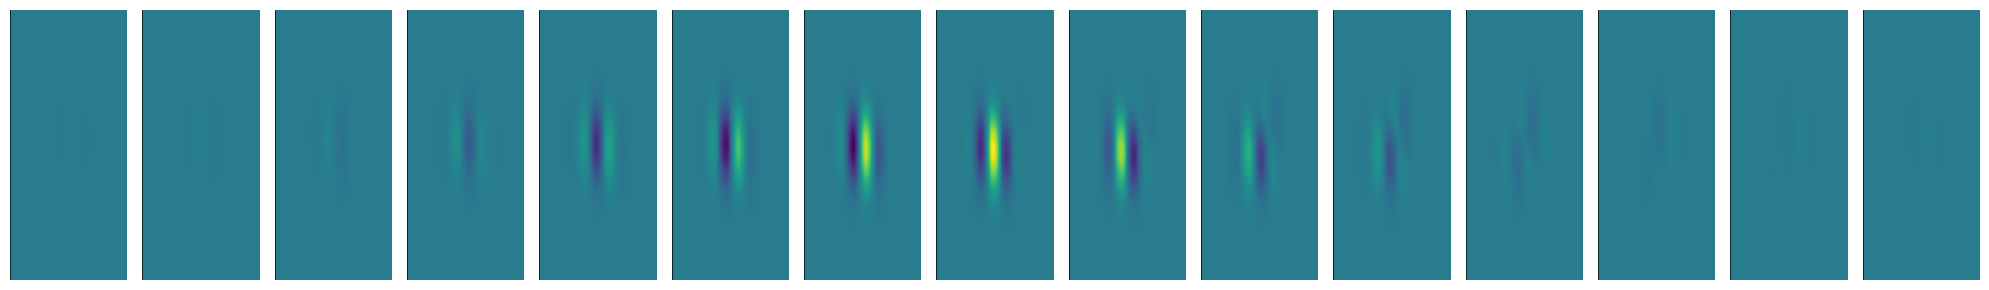

torch.Size([40, 128, 128])


In [7]:
fig = plt.figure(figsize=(20, 3))
afilter = filters['spatiotemporal']['re']['1-0-1']
nslicestot = afilter.shape[0]
vmin = torch.min(afilter)
vmax = torch.max(afilter)
nslices = 15
slices = np.linspace(0,nslicestot-1,nslices,dtype=int)
f=0
for i in slices:
    f+=1
    plt.subplot(1,nslices,f)
    plt.pcolormesh(afilter[i,:,:],vmin=vmin,vmax=vmax)
    plt.axhline(0,color='black',linewidth = 0.5) # x = 0
    plt.axvline(0,color='black',linewidth = 0.5) # y = 0
    plt.axis('off')
plt.tight_layout()
plt.show()
print(afilter.shape)

In [8]:
afilter.shape, movie.shape, fftmov.shape

(torch.Size([40, 128, 128]),
 torch.Size([1, 1, 80, 500, 500]),
 torch.Size([1, 1, 80, 500, 500]))

## Pad Filer to Match movie

torch.Size([40, 128, 128])
torch.Size([1, 1, 80, 500, 500])
torch.Size([1, 1, 80, 500, 500])


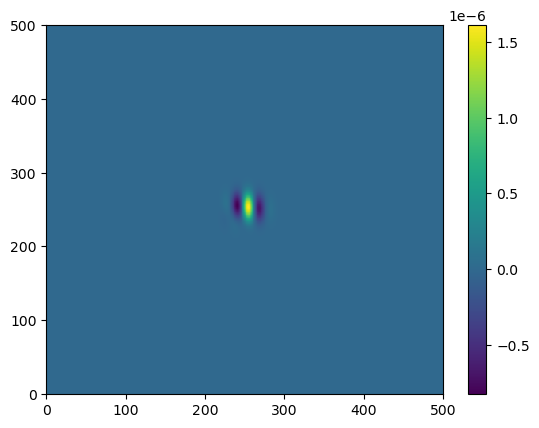

In [9]:
import torch.nn.functional as F

def pad_filter(filter, intput):
    filter_shape = filter.size()
    input_shape = intput.size()
    #print(filter_shape, input_shape)
    
    # Calculate padding
    pad_depth = (input_shape[2] - filter_shape[2]) // 2
    pad_height = (input_shape[3] - filter_shape[3]) // 2
    pad_width = (input_shape[4] - filter_shape[4]) // 2
    
    # If the difference is odd, add the extra padding to one side
    pad_front = pad_depth
    pad_back = pad_depth + (input_shape[2] - filter_shape[2]) % 2
    pad_top = pad_height
    pad_bottom = pad_height + (input_shape[3] - filter_shape[3]) % 2
    pad_left = pad_width
    pad_right = pad_width + (input_shape[4] - filter_shape[4]) % 2

    filter_padded = F.pad(filter, (pad_left, pad_right, pad_top, pad_bottom, pad_front, pad_back), "constant", 0)
    return(filter_padded)


# Apply padding
afilter_padded = afilter.unsqueeze(0).unsqueeze(0)
afilter_padded = pad_filter(afilter_padded, movie) #pad in spatial domain
print(afilter.size())
print(fftmov.size())
print(afilter_padded.size())
plt.pcolormesh(afilter_padded[0,0,20,:,:].cpu().detach())
plt.colorbar()
plt.show()


## Convolve Filer Bank with Test Video

In [10]:
#pick the approrpiate one for this device
#device = torch.device('cuda')
#device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
device=('cpu')

movie = movie.to(device)

real_filters = []
imag_filters = []
st_real_filters = []
st_imag_filters = []
real_outputs = []
imag_outputs = []
filter_names = list(filters['fourier']['re'].keys())
#filter_names = list(filters['spatiotemporal']['re'].keys())
#loop thorugh filters
for filter_name in keys: #filter_names:
    st_real_filter = filters['spatiotemporal']['re'][filter_name].unsqueeze(0).unsqueeze(0).float().to(device) #add another unsqueeze(0) for batch dim
    st_imag_filter = filters['spatiotemporal']['im'][filter_name].unsqueeze(0).unsqueeze(0).float().to(device)
    st_real_filters.append(st_real_filter)
    st_imag_filters.append(st_imag_filter)
    real_filter = filters['fourier']['re'][filter_name].unsqueeze(0).unsqueeze(0).float().to(device) #add another unsqueeze(0) for batch dim
    imag_filter = filters['fourier']['im'][filter_name].unsqueeze(0).unsqueeze(0).float().to(device)
    real_filters.append(real_filter)
    imag_filters.append(imag_filter)
    

    # Convolve in for loop - this is too slow. replace it with batched forward version.
    #full 3d
    #real_conv = F.conv3d(movie, real_filter, padding='same')
    #imag_conv = F.conv3d(movie, imag_filter, padding='same')    

    #instead of direct convolution pad and multiply with the FFT
    real_filter_pad = pad_filter(st_real_filter, fftmov)
    imag_filter_pad = pad_filter(st_imag_filter, fftmov) #pad in spatial domain
    real_conv = torch.fft.ifftshift(torch.fft.ifftn(torch.fft.fftn(movie) * torch.fft.fftn(real_filter_pad)))
    imag_conv = torch.fft.ifftshift(torch.fft.ifftn(torch.fft.fftn(movie) * torch.fft.fftn(imag_filter_pad)))
    #real_conv = torch.fft.ifftn(fftmov * torch.fft.fftshift(real_filter_pad))
    #imag_conv = torch.fft.ifftn(fftmov * torch.fft.fftshift(imag_filter_pad))
    # plt.imshow(movie[0,0,20,:,:])
    # plt.show()
    # plt.imshow(st_real_filter[0,0,20,:,:])
    # plt.show()
    # plt.imshow(real_filter_pad[0,0,20,:,:])
    # plt.show()
    # plt.imshow(real_conv.real[0,0,5,:,:])
    # plt.show()
    #append
    real_outputs.append(real_conv)
    imag_outputs.append(imag_conv)
    print('*',end='')
print('done')

st_real_filters = torch.stack(st_real_filters)
st_imag_filters = torch.stack(st_imag_filters)
real_filters = torch.stack(real_filters)
imag_filters = torch.stack(imag_filters)
real_outputs = torch.stack(real_outputs)
imag_outputs = torch.stack(imag_outputs)


torch.save(real_outputs, './real_outputs.pt')
torch.save(imag_outputs, './imag_outputs.pt')
# real_filter.shape
# plt.imshow(real_filter[0,0,30,:,:].cpu().detach())
# plt.show()


************************************************************************************************************************done


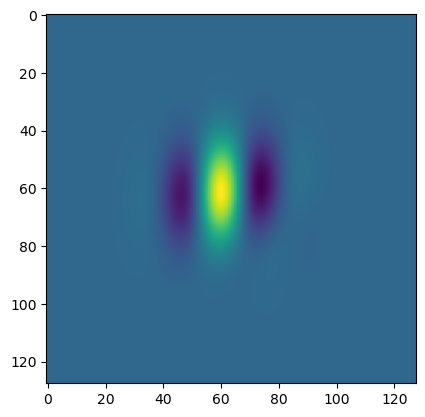

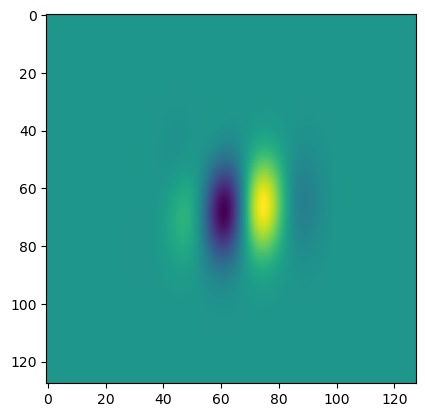

In [11]:
rf = st_real_filters[0][0,0,20,:,:]
plt.imshow(rf)
plt.show()
im = st_imag_filters[0][0,0,20,:,:]
plt.imshow(im)

1-0-1


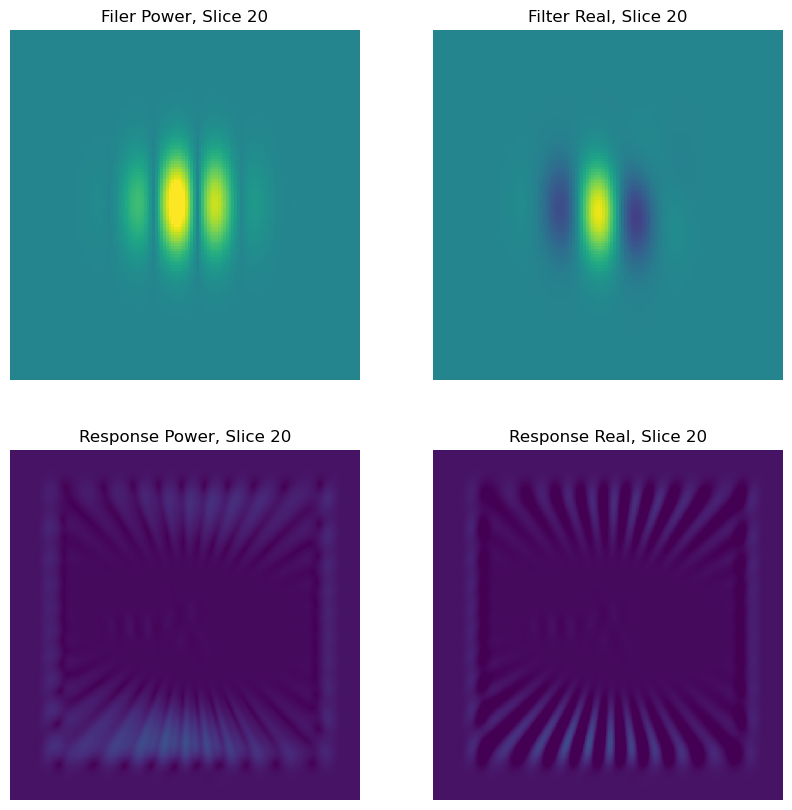

1-0-2


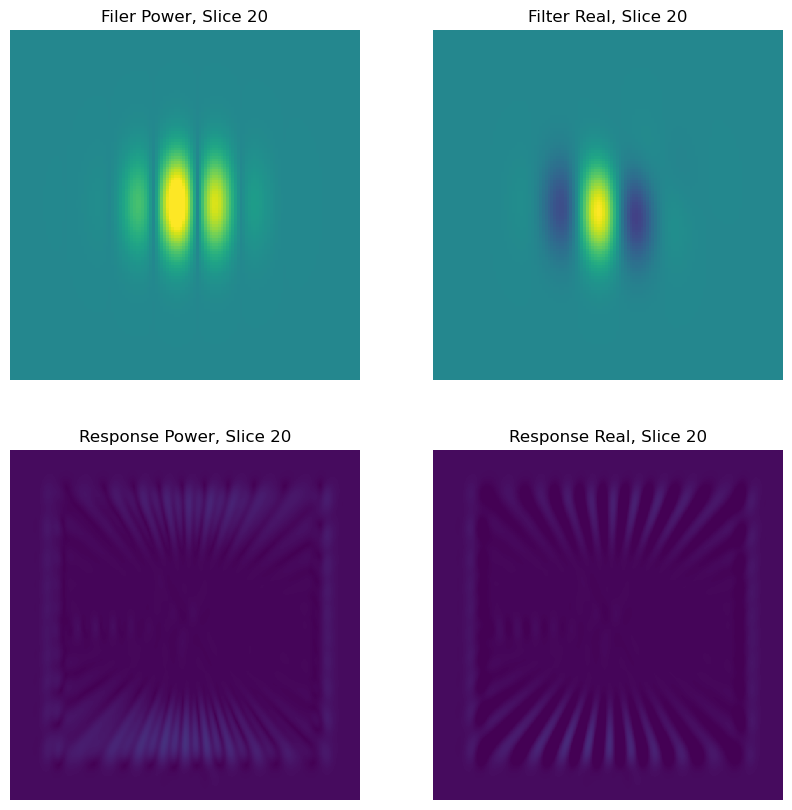

1-0-4


In [ ]:
import matplotlib.animation as animation
import os
from IPython.display import Video

# Create output directory
output_dir = f'test_movies_output_norm{normalize}_{filter_banks_size}'
os.makedirs(output_dir, exist_ok=True)

def create_movie(filter_real, filter_imag, output_real, output_imag, filename, fmin=None, fmax=None,rmin=None, rmax=None):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
    nslices = nslicestot
    slices = np.linspace(0, nslices-1, nslices, dtype=int)

    frmin = np.min(np.real(filter_real))
    frmax = np.max(np.real(filter_imag))
    fmin = np.min(np.real(filter_real+1j*filter_imag)**2)
    fmax = np.max(np.real(filter_real+1j*filter_imag)**2)
    fmin = np.min((filter_real,filter_imag))
    fmax = np.max((filter_real,filter_imag))

    def update_plot(frame):
        slice_idx = slices[frame]
        axes[0,0].clear()
        axes[0,1].clear()
        axes[1,0].clear()
        axes[1,1].clear()
        #Filter
        #print(filter_real.shape)
        axes[0,0].pcolormesh(np.real(np.sqrt(filter_real[0,0,slice_idx,:,:]**2 + filter_imag[0,0,slice_idx,:,:]**2)),vmin=fmin,vmax=fmax)
        axes[0,0].set_aspect('equal')
        axes[0,0].set_title(f'Filer Power, Slice {slice_idx}')
        axes[0,1].pcolormesh(filter_real[0,0,slice_idx,:,:],vmin=fmin,vmax=fmax)
        axes[0,1].set_aspect('equal')
        axes[0,1].set_title(f'Filter Real, Slice {slice_idx}')
       
        #Response
        #axes[1,0].pcolormesh(output_real[0,0,slice_idx,:,:])#, vmin=vmin, vmax=vmax)
        axes[1,0].pcolormesh(np.real(np.sqrt(output_real[0,0,slice_idx,:,:]**2 + output_imag[0,0,slice_idx,:,:]**2)),vmin=rmin,vmax=rmax)
        axes[1,0].set_aspect('equal')
        axes[1,0].set_title(f'Response Power, Slice {slice_idx}')
        axes[1,1].pcolormesh(np.real(output_real[0,0,slice_idx,:,:]),vmin=rmin,vmax=rmax)#, vmin=vmin, vmax=vmax)
        axes[1,1].set_aspect('equal')
        axes[1,1].set_title(f'Response Real, Slice {slice_idx}')
        for ax in [axes[0,0],axes[0,1],axes[1,0],axes[1,1]]:
            # ax.axhline(0, color='black',linewidth = 0.25) # x = 0
            # ax.axvline(0, color='black',linewidth = 0.25) # y = 0
            ax.axis('off')
        if(frame==nslices//2):
            plt.show()

    ani = animation.FuncAnimation(fig, update_plot, frames=nslices, repeat=False)
    ani.save(filename, writer='ffmpeg', fps=30)
    plt.close(fig)

fmin = np.min((st_real_filters.cpu().numpy(), st_imag_filters.cpu().numpy()))
fmax = np.max((st_real_filters.cpu().numpy(), st_imag_filters.cpu().numpy()))
pow = np.real(np.sqrt(real_outputs.cpu().numpy()**2 + imag_outputs.cpu().numpy()**2))
rmin = np.min(pow)
rmax = np.max(pow)

for i in range(len(real_outputs)):

    filter_real = st_real_filters[i].cpu().numpy()
    filter_imag = st_imag_filters[i].cpu().numpy()
    fourier_filter_real = real_filters[i].cpu().numpy()
    fourier_filter_imag = imag_filters[i].cpu().numpy()
    output_real = real_outputs[i].cpu().numpy()
    output_imag = imag_outputs[i].cpu().numpy()

    print(filter_names[i])
    #print(output_real.shape)
    #print(output_imag.shape)
    
    filename = os.path.join(output_dir, f'test_response_{filter_names[i]}.mp4')
    create_movie(filter_real, filter_imag, output_real, output_imag, filename,fmin=fmin, fmax=fmax,rmin=rmin, rmax=rmax)
#show the last video
Video(filename)

In [ ]:
filter_shape, mov_shape

In [ ]:
nslicestot

In [ ]:
real_filter.shape